In [1]:
import os
import torch
import torch.optim as optim
import torch.nn as nn
import segmentation_models_pytorch as smp
from fastai.losses import DiceLoss, CrossEntropyLossFlat

from matrices import *
from preprocessing import *
from utils import *

In [2]:
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.backends.cudnn.is_available())
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_device(device)
print(f"Using {device} device")
generator = torch.Generator(device=device)

2.11.0+cu126
True
True
Using cuda device


In [3]:
# Locate project root and TACK data folders dynamically relative to the script location
base_dir = os.getcwd()
dataset_folder = os.path.join(base_dir, "TACK_Tunnel_Data")

csv_source_dir = os.path.join(dataset_folder, "2_model_input")
raw_mask_dir = os.path.join(dataset_folder, "3_mask")

# Initialize pipeline pointing to the TTD dataset structure
pipeline = TunnelDataPipeline(
    base_dir=dataset_folder,
    original_mask_dir=raw_mask_dir
)

# Define standard training splits for the multi-domain tunnel study
train_files = ["TA_train.csv"]
val_files = ["TA_val.csv"]
test_files = ["TA_test.csv"]

# Step 1: Load metadata
print("Loading CSV metadata...")
df_train_val, df_test = pipeline.load_csv_data(
    csv_source_dir=csv_source_dir,
    train_files=train_files,
    val_files=val_files,
    test_files=test_files
)

# Step 2: Sanitize and separate training/validation masks
print("Sanitizing training and validation masks...")
df_train_val_ready = pipeline.sanitize_masks(df_train_val, class_pixel_value=40)

# Step 3: Sanitize test masks
print("Sanitizing test masks...")
df_test_ready = pipeline.sanitize_masks(df_test, class_pixel_value=40)

# Step 4: Compute dataset-specific normalization values
custom_stats = None # use imagenet for baseline

# Step 5: Finalize DataLoaders for the training loop
print("Generating Dataloaders...")
train_dl, val_dl, test_dl = pipeline.get_dataloaders(
    train_val_df=df_train_val_ready,
    test_df=df_test_ready,
    bs=16,
    img_size=512,
    custom_stats=custom_stats
)

# Final summary of training readiness
print(f"\nPipeline Ready:")
print(f" - Training batches: {len(train_dl)}")
print(f" - Validation batches: {len(val_dl)}")
print(f" - Testing batches: {len(test_dl)}")

Loading CSV metadata...
Sanitizing training and validation masks...


Sanitizing Masks: 100%|██████████| 604/604 [00:00<00:00, 7232.53it/s]


Sanitizing test masks...


Sanitizing Masks: 100%|██████████| 70/70 [00:00<00:00, 6364.65it/s]

Generating Dataloaders...



Pipeline Ready:
 - Training batches: 29
 - Validation batches: 9
 - Testing batches: 5


In [4]:
import torch
import torch.nn as nn
from fastai.losses import DiceLoss, CrossEntropyLossFlat

class TTDCombinedLoss(nn.Module):
    def __init__(self, ce_weight_tensor, w_ce=0.5, w_dice=0.5):
        """
        Hybrid loss combining Weighted Cross-Entropy and Dice Loss[cite: 233, 241].
        """
        super().__init__()
        self.w_ce, self.w_dice = w_ce, w_dice
        # Weighted CE handles the <0.5% crack pixel density [cite: 238, 242, 247]
        self.ce_loss = CrossEntropyLossFlat(weight=ce_weight_tensor, axis=1)
        # Dice Loss focuses on regional overlap [cite: 234, 235]
        self.dice_loss = DiceLoss(axis=1)

    def forward(self, pred, targ):
        # Cast to standard tensors to prevent fastai subclass conflicts
        pred_tensor = pred.as_subclass(torch.Tensor)
        targ_tensor = targ.as_subclass(torch.Tensor).long()
        
        ce = self.ce_loss(pred_tensor, targ_tensor)
        dice = self.dice_loss(pred_tensor, targ_tensor)
        return self.w_ce * ce + self.w_dice * dice

In [5]:
num_epoch = 100
model = smp.Unet("resnet34", encoder_weights="imagenet", classes=2)
model_name = "Unet-resnet34-imagenet"
optimizer = optim.AdamW(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, num_epoch, eta_min=5e-7)

weights = torch.tensor([1.0, 20.0]).to(device)
loss_fn = TTDCombinedLoss(ce_weight_tensor=weights, w_ce=0.5, w_dice=0.5)

history = epochs(model, model_name, device, train_dl, val_dl, loss_fn, optimizer, num_epoch)

Epoch 0: T-Loss: 10.4349 | V-Loss: 9.8606 | IoU: 0.0205 | F1: 0.0401 [Saved Best Model]
Epoch 1: T-Loss: 9.0577 | V-Loss: 8.5441 | IoU: 0.1645 | F1: 0.2746 [Saved Best Model]
Epoch 2: T-Loss: 8.5990 | V-Loss: 8.3050 | IoU: 0.2066 | F1: 0.3364 [Saved Best Model]
Epoch 3: T-Loss: 8.2556 | V-Loss: 8.0762 | IoU: 0.2764 | F1: 0.4213 [Saved Best Model]
Epoch 4: T-Loss: 8.0299 | V-Loss: 7.8077 | IoU: 0.4110 | F1: 0.5746 [Saved Best Model]
Epoch 5: T-Loss: 7.8837 | V-Loss: 9.7996 | IoU: 0.1111 | F1: 0.1957
Epoch 6: T-Loss: 7.7460 | V-Loss: 7.4733 | IoU: 0.4833 | F1: 0.6462 [Saved Best Model]
Epoch 7: T-Loss: 7.5329 | V-Loss: 7.3484 | IoU: 0.4708 | F1: 0.6342
Epoch 8: T-Loss: 7.3778 | V-Loss: 7.1682 | IoU: 0.4895 | F1: 0.6508 [Saved Best Model]
Epoch 9: T-Loss: 7.2097 | V-Loss: 7.0737 | IoU: 0.4596 | F1: 0.6235
Epoch 10: T-Loss: 7.0201 | V-Loss: 6.9491 | IoU: 0.4740 | F1: 0.6370
Epoch 11: T-Loss: 6.9156 | V-Loss: 6.6782 | IoU: 0.5888 | F1: 0.7363 [Saved Best Model]
Epoch 12: T-Loss: 6.7240 | V-

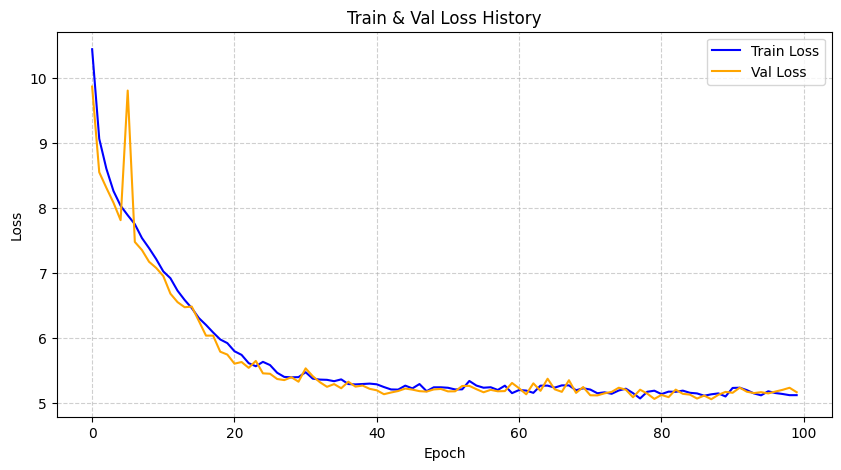

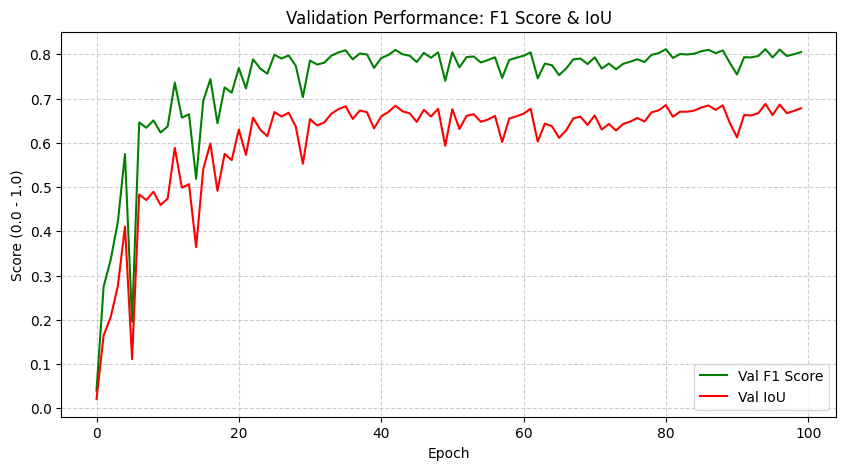

In [6]:
plot_training_history(history)

In [7]:
model = smp.Unet("resnet34", encoder_weights="imagenet", classes=2)
model.load_state_dict(torch.load(f"{model_name}.pth"))
v_loss, v_iou, v_f1 = val_loop(model, device, test_dl, loss_fn)
print("Test stats")
print(f"Loss: {v_loss:.4f} | IoU: {v_iou:.4f} | F1: {v_f1:.4f}")

Test stats
Loss: 4.8927 | IoU: 0.7501 | F1: 0.8565
